<a href="https://colab.research.google.com/github/NegasaReta/Elevvo-Internship-Machine-Learning-Track/blob/Task1/Task_1_Student_Score_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

##1) Load the Dataset

In [1]:
CSV_PATH = "/content/StudentPerformanceFactors.csv"

In [ ]:
df = pd.read_csv(CSV_PATH)

In [ ]:
df.head ()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.shape

(6607, 20)

##Select Feature Target

In [ ]:
FEATURE_COL = "Hours_Studied"
TARGET_COL = "Exam_Score"

# Keep only needed columns for Task 1
data = df [[FEATURE_COL, TARGET_COL]].copy ()


##2) Data Cleaning

In [ ]:
data [FEATURE_COL] = pd.to_numeric (data [FEATURE_COL], errors="coerce")
data [TARGET_COL] = pd.to_numeric (data [TARGET_COL], errors="coerce")
data = data.dropna ()

print ("Rows after cleaning:", len (data))
print (data.describe ())


Rows after cleaning: 6607
       Hours_Studied   Exam_Score
count    6607.000000  6607.000000
mean       19.975329    67.235659
std         5.990594     3.890456
min         1.000000    55.000000
25%        16.000000    65.000000
50%        20.000000    67.000000
75%        24.000000    69.000000
max        44.000000   101.000000


##3) Basic Visualization

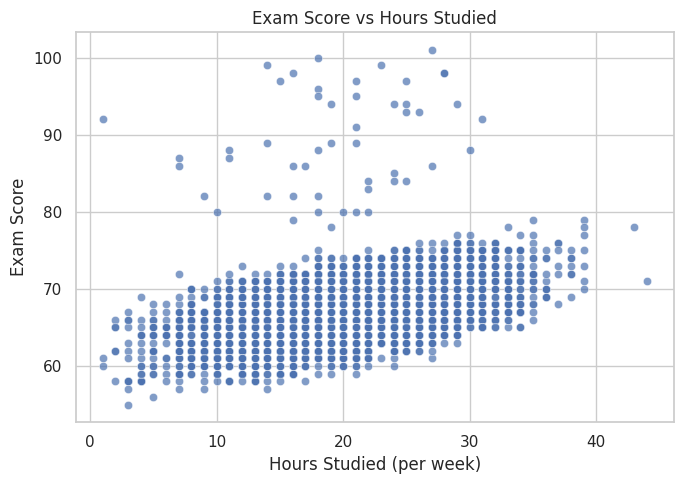

Correlation(Hours_Studied, Exam_Score): 0.4455


In [ ]:
sns.set (style="whitegrid")
plt.figure (figsize=(7, 5))

sns.scatterplot (x=data[FEATURE_COL], y=data[TARGET_COL], alpha=0.7)
plt.title ("Exam Score vs Hours Studied")
plt.xlabel ("Hours Studied (per week)")
plt.ylabel ("Exam Score")
plt.tight_layout ()
plt.show ()

corr = data [[FEATURE_COL, TARGET_COL]].corr (numeric_only=True).iloc [0,1]
print (f"Correlation(Hours_Studied, Exam_Score): {corr:.4f}")



##4) Train / Test Split

In [ ]:
X = data [[FEATURE_COL]].values
y = data [TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.2, random_state=42
)

##5) Train Linear Regression

In [ ]:
model = LinearRegression ()
model.fit (X_train, y_train)

print ("\nLinear Regression equation:")
print (f"Exam_Score = {model.intercept_:.4f} + {model.coef_[0]:.4f} * Hours_Studied")



Linear Regression equation:
Exam_Score = 61.5112 + 0.2857 * Hours_Studied


##6) Predict + evaluate

In [ ]:
y_pred = model.predict (X_test)
mae = mean_absolute_error (y_test, y_pred)
mse = mean_squared_error (y_test, y_pred)
rmse = np.sqrt (mse)
r2 = r2_score (y_test, y_pred)

print ("\n Test set metrics:")
print (f"MAE : {mae:.4f}")
print (f"MSE : {mse:.4f}")
print (f"RMSE: {rmse:.4f}")
print (f"R^2 : {r2:.4f}")


 Test set metrics:
MAE : 2.4476
MSE : 10.8559
RMSE: 3.2948
R^2 : 0.2320


## 7) Visualize predictions

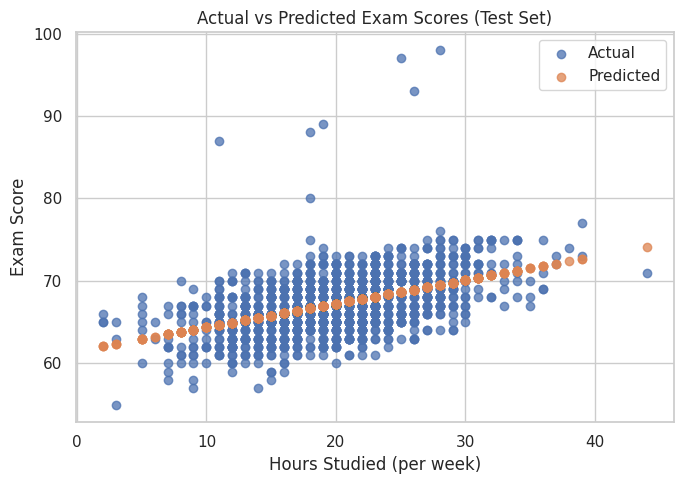

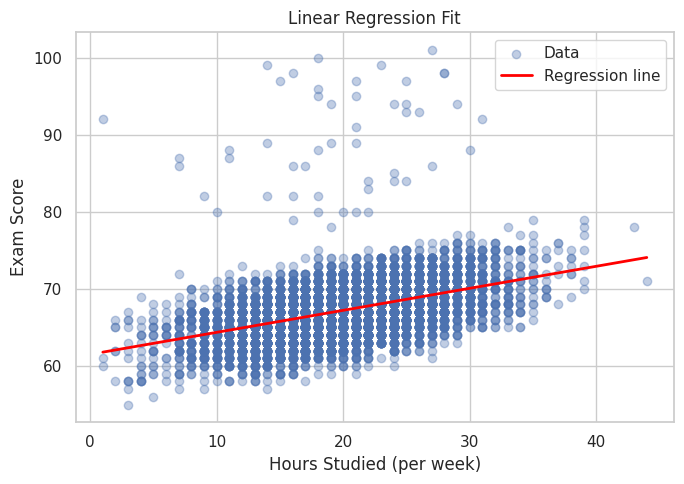

In [ ]:
plt.figure (figsize = (7,5))
plt.scatter (X_test.flatten (), y_test, label="Actual", alpha=0.75)
plt.scatter (X_test.flatten (), y_pred, label="Predicted", alpha=0.75)
plt.title ("Actual vs Predicted Exam Scores (Test Set)")
plt.xlabel ("Hours Studied (per week)")
plt.ylabel ("Exam Score")
plt.legend ()
plt.tight_layout ()
plt.show ()

#Regression line over full range
x_line = np.linspace (data[FEATURE_COL].min(), data[FEATURE_COL].max(), 200).reshape (-1,1)
y_line = model.predict(x_line)

plt.figure (figsize = (7,5))
plt.scatter (data[FEATURE_COL],data[TARGET_COL], alpha= 0.35, label = "Data" )
plt.plot (x_line.flatten (), y_line, color = "red", linewidth = 2, label = "Regression line")
plt.title ("Linear Regression Fit")
plt.xlabel ("Hours Studied (per week)")
plt.ylabel ("Exam Score")
plt.legend()
plt.tight_layout ()
plt.show ()


## 8) Example prediction

In [ ]:
example_hours = 30
pred_score = model.predict (np.array([[example_hours]]))[0]
print (f"\nPredicted Exam_Score for {example_hours} hours studied/week: {pred_score:.2f}")


Predicted Exam_Score for 30 hours studied/week: 70.08


## Task 1: Student Score Prediction (Hours Studied → Exam Score)

### Objective
Build a baseline model to predict students’ **final exam score** (`Exam_Score`) using only their **weekly study hours** (`Hours_Studied`).

### Method
- Selected `Hours_Studied` as the single input feature and `Exam_Score` as the target.
- Cleaned the data by removing missing/non-numeric values in these columns.
- Split the dataset into training and testing sets.
- Trained a **Linear Regression** model.
- Evaluated performance on the test set using **MAE**, **MSE**, **RMSE**, and **R²**.

### Results (Test Set)
- **MAE:** 2.4476  
- **MSE:** 10.8559  
- **RMSE:** 3.2948  
- **R²:** 0.2320  

### Interpretation
The model’s **MAE (2.4476)** and **RMSE (3.2948)** indicate the predictions are typically within about **2–3 score points** of the true exam scores. However, the **R² value of 0.2320** shows that `Hours_Studied` explains only about **23.2%** of the variation in exam performance. This suggests study time has a meaningful relationship with exam score, but **many other factors** (e.g., attendance, previous scores, motivation, access to resources) also play a significant role.

### Conclusion
A single-feature Linear Regression model using `Hours_Studied` provides a useful **baseline**, but its relatively low R² indicates that a more accurate predictor would require incorporating additional student and school-related features.

### Next Steps (Optional)
- Train a multivariate regression model using additional features (e.g., `Previous_Scores`, `Attendance`, `Motivation_Level`, `Access_to_Resources`) and compare metrics to this baseline.
- Try regularized linear models (Ridge/Lasso) to reduce overfitting and handle correlated features.